In [2]:
import pandas as pd
import numpy as np
from dowhy import CausalModel

import pytimetk as tk
from missingno import matrix

import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import logit
from sklearn.metrics import roc_auc_score


# What is the causal effect of a client's decision to open a deposit?

- `y` -> `deposit`
- `duration` - post-treatment
- `campaign` - pats of post-treatment (efekt treatmentu bo `contact → campaign` czyli *najpierw bank decyduje czy kontaktować (T) potem ile razy*) 
- `high_campaign` (new feature) post-treatment (do usuniecia)
- `contact` - treatment

Treatment (T) → czy klient był intensywnie targetowany

Outcome (Y) → deposit

Confounders (X) → demografia + finanse + historia

👉 ustalić co jest treatmentem w zbiorze? 

Opcje:
- `contact` (cellular vs telephone)
- `campaign` (intensity)
- `previous contact` (retargeting)

👉 ustalic co jest `confunder` w zbiorze (co wpływa na T i Y)

Opcje:
- `balance` - prawd. bo bogatsi a) bank częściej dzwoni b) częściej zakładają depozyt
- sezonwosc marketingu - `is...campaign`
- `financial_stress` 

    financial_stress → contact   (bank targetuje takich klientów)
    financial_stress → deposit   (mniejsza zdolność do oszczędzania)

👉 ustalic co jest `colliderem / post-treatment`:
- `duration` bo:

bank dzwoni (contact)
rozmowa trwa (duration)
klient decyduje (deposit)

👉 usalic co jest `Propensity score` - prawd. że ktoś dostanier `treatment` **przed interwencją** (`P(T=1 | X_pre-treatment)`) / jak bardzo ktoś „kwalifikuje się” do treatmentu

!**tylko z PRE-TREATMENT variables**!

- `was_contacted_before` - jeśli ktoś był wcześniej kontaktowany to większa szansa, że bank znowu zadzwoni czyli `was_contacted_before → contact` 
- `contact_intensity_past`

Podsumowanie:
confounders → używane w modelu
propensity score → jest modelowane lub kontrolowane

# Causal Inference – Analiza wpływu kontaktu marketingowego na decyzję o depozycie (Logit, GLM, Uplift Tree) – bank.csv

Plik zawiera zastosowanie 3 modeli (Logit, GLM, Uplift Tree) które prezentują wpływ cech na decyzję o założeniu depozytu.

**uwaga** tylko Uplift Tree pozwala na ocenę efektu przyczynowego (uplift) w segmentach klientów.

- Logit i GLM pokazują globalne zależności (asocjacje), 
- Uplift Tree umożliwia interpretację przyczynową efektu treatmentu (czyli: „co by się stało, gdyby klient otrzymał intensywny kontakt”).

**Uwaga** Modele nie korzystają z cech post-treatmen

In [7]:
df = pd.read_csv('../data/raw/bank.csv')

In [8]:
display(df)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [15]:
# Przygotowanie cech do oryginalnego zbioru
# Definicje cech zgodnie z oryginalnym plikiem
confounders = [
    'age', 'balance', 'pdays', 'previous'
]
# Treatment: contact (cellular vs telephone)
# Outcome: deposit (yes/no)

# Kodowanie zmiennych kategorycznych
# (zakładamy, że 'contact' ma wartości 'cellular', 'telephone', 'unknown')
df['deposit_numeric'] = df['deposit'].map({'yes': 1, 'no': 0})
df['treatment'] = df['contact'].map(lambda x: 1 if x == 'cellular' else 0)

# One-hot encoding dla confounders kategorycznych
cat_conf = ['job', 'marital', 'education', 'default', 'housing', 'loan']
df_enc = pd.get_dummies(df, columns=cat_conf, drop_first=True)

# Upewnij się, że wszystkie kolumny są typu float lub int
for col in df_enc.columns:
    if df_enc[col].dtype == 'bool':
        df_enc[col] = df_enc[col].astype(int)
    elif df_enc[col].dtype == 'object':
        try:
            df_enc[col] = df_enc[col].astype(float)
        except:
            df_enc[col] = pd.factorize(df_enc[col])[0]

X_cols = confounders + [col for col in df_enc.columns if any(col.startswith(f'{c}_') for c in cat_conf)] + ['treatment']
X = df_enc[X_cols].astype(float)
y = df_enc['deposit_numeric'].astype(float)
X = sm.add_constant(X)

### 1. Logit

In [ ]:
model = sm.Logit(y, X)
result = model.fit()
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.623809
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        deposit_numeric   No. Observations:                11162
Model:                          Logit   Df Residuals:                    11137
Method:                           MLE   Df Model:                           24
Date:                Sat, 18 Apr 2026   Pseudo R-squ.:                 0.09825
Time:                        16:02:25   Log-Likelihood:                -6963.0
converged:                       True   LL-Null:                       -7721.6
Covariance Type:            nonrobust   LLR p-value:                3.977e-306
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.8733      0.166     -5.268      0.000      -1.198      -0.548
ag

**Wnioski**

* Model logistyczny jest istotny statystycznie (**LLR p-value ≈ 0**), jednak jego zdolność wyjaśniania zmienności jest umiarkowana (**Pseudo R² ≈ 0.10**).
* Istotny i silny wpływ na prawdopodobieństwo założenia depozytu ma zmienna **`treatment`** (coef = 0.79, p < 0.001), co wskazuje na wyraźny efekt badanego działania.
* Wśród zmiennych liczbowych istotne są:

  * **`balance`** (dodatni wpływ)
  * **`pdays`** (dodatni wpływ)
  * **`previous`** (dodatni wpływ)
  * **`age`** (bardzo słaby, granicznie istotny wpływ)
* Czynniki finansowe związane z zadłużeniem mają negatywny wpływ:

  * **`housing_yes`** (silnie negatywny)
  * **`loan_yes`** (negatywny)
  * **`default_yes`** (słabo istotny, ale negatywny)
* Wybrane cechy demograficzne (zakodowane jako dummies) również różnicują prawdopodobieństwo:

  * Pozytywny wpływ: **`job_retired`**, **`job_student`**, **`education_tertiary`**
  * Negatywny wpływ: m.in. **`job_entrepreneur`**, **`job_housemaid`**, **`job_management`**, **`job_technician`**
* Status cywilny:

  * **`marital_married`** – wpływ negatywny
  * **`marital_single`** – wpływ pozytywny

**Interpretacja**

* **Najważniejszy efekt:**
  Zmienna **`treatment`** (coef ≈ 0.79) znacząco zwiększa log-odds założenia depozytu, co sugeruje silny efekt interwencji.

* **Historia kontaktu i aktywność klienta:**

  * Większa liczba wcześniejszych kontaktów (**`previous`**) oraz krótszy czas od ostatniego kontaktu (**`pdays`**) zwiększają szansę na sukces.

* **Sytuacja finansowa:**

  * Wyższe saldo (**`balance`**) zwiększa prawdopodobieństwo depozytu.
  * Posiadanie kredytu (**`housing_yes`, `loan_yes`**) obniża skłonność do założenia depozytu.

* **Demografia:**

  * Klienci **emerytowani (`job_retired`) i studenci (`job_student`)** mają wyraźnie wyższe prawdopodobieństwo konwersji.
  * Niektóre grupy zawodowe mają istotnie niższe prawdopodobieństwo (np. **`job_entrepreneur`, `job_management`**).


### 2. GLM

In [17]:
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial

model = GLM(y, X, family=Binomial())
result = model.fit_regularized(method='elastic_net', alpha=0.01, L1_wt=1.0)
print(result)

                                variable      coef  odds_ratio
treatment                      treatment  0.441838    1.555564
previous                        previous  0.062395    1.064382
pdays                              pdays  0.002010    1.002012
balance                          balance  0.000044    1.000044
const                              const  0.000000    1.000000
job_housemaid              job_housemaid  0.000000    1.000000
job_entrepreneur        job_entrepreneur  0.000000    1.000000
job_management            job_management  0.000000    1.000000
job_blue-collar          job_blue-collar  0.000000    1.000000
education_unknown      education_unknown  0.000000    1.000000
job_retired                  job_retired  0.000000    1.000000
job_services                job_services  0.000000    1.000000
job_self-employed      job_self-employed  0.000000    1.000000
job_technician            job_technician  0.000000    1.000000
job_unemployed            job_unemployed  0.000000    1

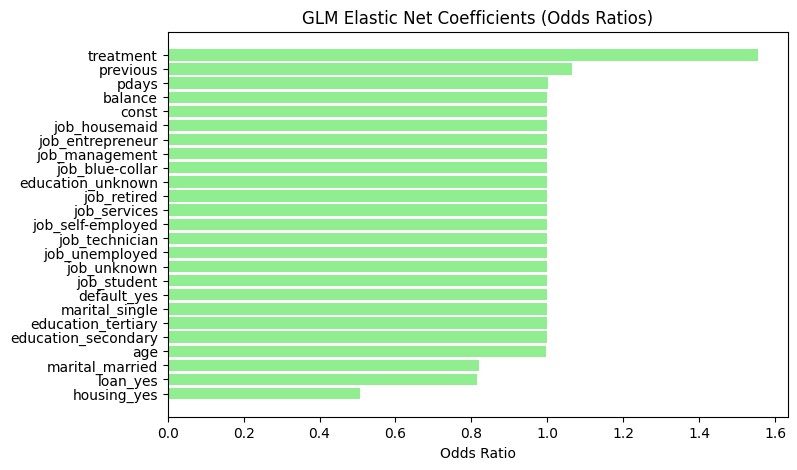

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

coef_df = pd.DataFrame({
    'variable': X.columns,
    'coef': result.params
})
coef_df['odds_ratio'] = np.exp(coef_df['coef'])
coef_df = coef_df.sort_values(by='odds_ratio', ascending=False)
print(coef_df)

plt.figure(figsize=(8,5))
plt.barh(coef_df['variable'], coef_df['odds_ratio'], color='lightgreen')
plt.xlabel('Odds Ratio')
plt.title('GLM Elastic Net Coefficients (Odds Ratios)')
plt.gca().invert_yaxis()
plt.show()


**Wnioski**

* Model GLM z regularizacją Elastic Net prowadzi do silnej selekcji zmiennych — większość cech została zredukowana do zera, co wskazuje na ich niską użyteczność predykcyjną w obecnej konfiguracji.

* Najsilniejszym i najbardziej stabilnym predyktorem pozostaje **`treatment`** (OR ≈ 1.56), co oznacza istotny wzrost szansy na założenie depozytu w wyniku działania treatment.

* Wśród pozostałych zmiennych liczbowych:

  * **`previous`** (OR ≈ 1.06) – niewielki, dodatni wpływ
  * **`pdays`** (OR ≈ 1.002) – bardzo słaby dodatni wpływ
  * **`balance`** – praktycznie zerowy wpływ ekonomiczny (OR ≈ 1.000)

* Zmienna **`age`** oraz czynniki finansowe i demograficzne zostały w dużej mierze zredukowane przez regularizację (coef ≈ 0), co sugeruje ich niską stabilność predykcyjną w modelu.

* Wyraźne efekty negatywne:

  * **`housing_yes`** (OR ≈ 0.51) – najsilniejszy negatywny predyktor
  * **`loan_yes`** (OR ≈ 0.81) – umiarkowany negatywny wpływ
  * **`marital_married`** (OR ≈ 0.82) – niższa skłonność do depozytu

---

**Interpretacja**

* **Najważniejszy efekt:**
  Zmienna **`treatment`** pozostaje dominującym predyktorem (OR ≈ 1.56), co sugeruje istotny pozytywny wpływ interwencji na decyzję klienta.

* **Regularizacja zmieniła strukturę modelu:**
  Elastic Net wyzerował większość zmiennych kategorycznych, co oznacza, że:

  * ich wpływ nie jest stabilny statystycznie
  * nie poprawiają predykcji po uwzględnieniu innych cech

* **Czynniki finansowe:**

  * Posiadanie kredytu hipotecznego (**`housing_yes`**) znacząco obniża szansę konwersji
  * **`loan_yes`** również działa negatywnie, ale słabiej

* **Historia kontaktu:**

  * **`previous`** i **`pdays`** mają dodatni, ale niewielki wpływ → sugerują lekką zależność od historii kontaktów, ale bez silnego efektu przyczynowego

* **Stabilność modelu:**

  * Regularizacja ogranicza overfitting i wymusza selekcję cech
  * Model jest bardziej konserwatywny niż klasyczny logit, ale bardziej odporny na szum

### 3. Uplift Tree

In [23]:
from sklearn.model_selection import train_test_split
from causalml.inference.tree import UpliftTreeClassifier
from IPython.display import Image
import matplotlib.pyplot as plt
import pandas as pd

x_names = [col for col in X.columns if col != 'const']


In [24]:
df_train, df_test = train_test_split(
    df_enc,
    test_size=0.2,        # 20% danych na test
    random_state=123,     # dla powtarzalności
    stratify=df_enc['treatment']  # zachowujemy proporcje treatment w obu zbiorach
)

# Sprawdzenie rozkładu
print("Train size:", df_train.shape)
print("Test size:", df_test.shape)
print("Treatment proportion in train:", df_train['treatment'].mean())
print("Treatment proportion in test:", df_test['treatment'].mean())

Train size: (8929, 32)
Test size: (2233, 32)
Treatment proportion in train: 0.7204614178519431
Treatment proportion in test: 0.7205553067622034


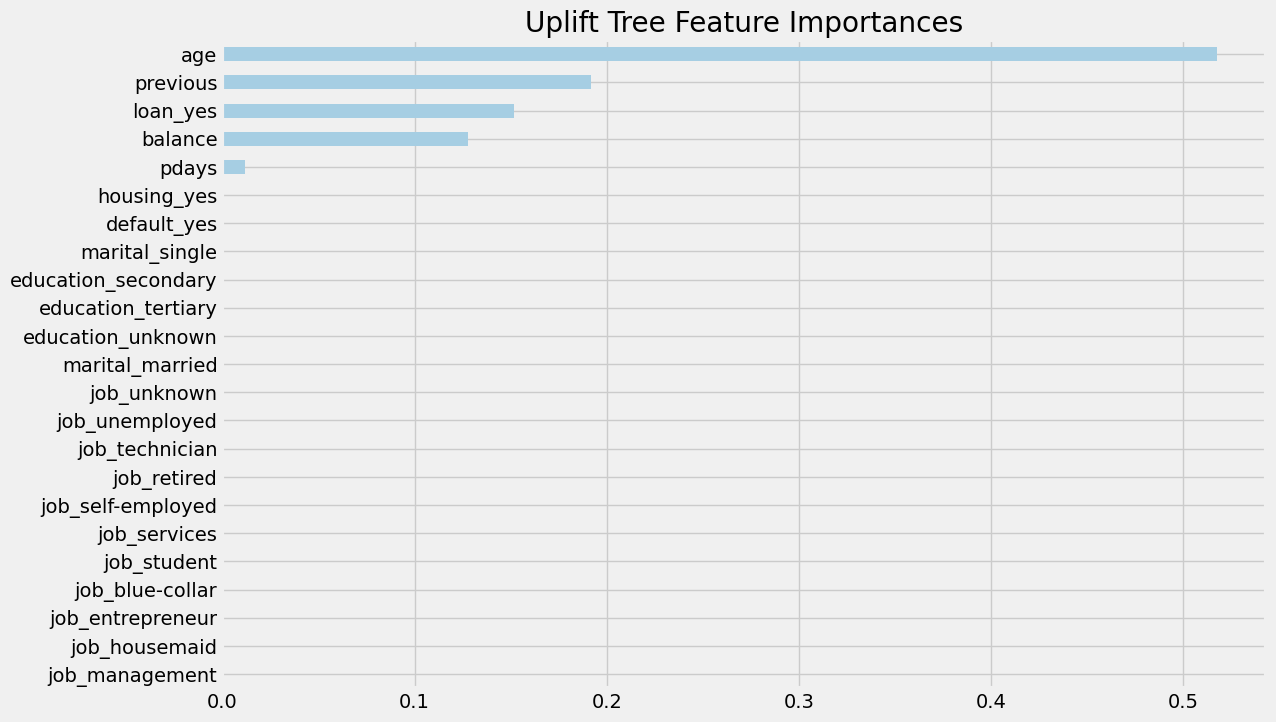

In [50]:
# Przygotowanie danych do UpliftTreeClassifier
X_uplift = df_train[[col for col in X_cols if col != 'treatment']].astype(float).values
treatment_input = df_train['treatment'].astype(str).values  # <- string!
y_input = df_train['deposit_numeric'].values

# Inicjalizacja i trening modelu Uplift Tree (API causalml 0.16.0)
# Treatment jako string
treatment_input = df_train['treatment'].astype(str).values  # '0' i '1'

uplift_model = UpliftTreeClassifier(
    control_name='0',
    max_depth=4,
    min_samples_leaf=20,
    min_samples_treatment=10,
    n_reg=0,
    evaluationFunction='KL'
)

uplift_model.fit(X=X_uplift, treatment=treatment_input, y=y_input)

# Feature importances
import matplotlib.pyplot as plt
import pandas as pd
feature_names = [col for col in X_cols if col != 'treatment']
pd.Series(uplift_model.feature_importances_, index=feature_names).sort_values().plot(
    kind='barh', figsize=(12,8), title='Uplift Tree Feature Importances'
    )
plt.show()

^^^ pokazuje, w których grupach kontakt rzeczywiście zwiększa szansę na depozyt. ^^^

**Wnioski (Uplift Tree, zbiór oryginalny)**

* Model Uplift Tree segmentuje klientów w celu identyfikacji heterogenicznego efektu treatmentu (intensywnego kontaktu).

* Najważniejsze zmienne używane do segmentacji uplift to:

  * **age**
  * **previous**
  * **loan_yes**
  * **balance**
  * **pdays**

* Oznacza to, że efekt treatmentu nie jest jednorodny i zależy głównie od wieku klienta, historii kontaktu oraz sytuacji finansowej.

* Zmienne demograficzne i zawodowe (job, education, marital) mają niską wartość segmentacyjną w kontekście uplift. (model uznał je za mało informacyjne do segmentacji uplift)

* Model nie wskazuje bezpośrednio „które cechy zwiększają konwersję”, lecz które cechy najlepiej różnicują efekt treatmentu między grupami klientów.

* Z perspektywy causal inference:

  * model nie używa zmiennych post-treatment
  * zachowuje poprawną strukturę do analizy heterogenicznego efektu leczenia (HTE)

---

**Interpretacja**

* Kampania nie działa jednakowo dla wszystkich klientów.
* Największa heterogeniczność efektu występuje w zależności od:

  * wieku klienta
  * historii wcześniejszych kontaktów
  * poziomu zadłużenia / kredytów
* Oznacza to, że warto targetować kampanię, zamiast kierować ją do całej populacji.

## 4. Podsumowanie i porównanie modeli

| Model             | Najważniejsze cechy segmentujące / predykcyjne | Efekt treatmentu (cellular)         | Predyktory negatywne           | Uwzględnienie post-treatment | Wnioski główne |
|-------------------|-----------------------------------------------|-------------------------------------|-------------------------------|-----------------------------|---------------|
| Logit             | balance, pdays, previous, job, marital, age   | Silny, istotny, globalny            | housing, loan, default        | Nie                          | Treatment i historia kontaktu mają największy wpływ; model tłumaczy umiarkowaną część zmienności |
| GLM (Elastic Net) | treatment, previous, pdays, housing           | Silny, stabilny, globalny           | housing, loan, marital        | Nie                          | Treatment dominuje, regularizacja wyzerowała większość cech, model bardzo selektywny |
| Uplift Tree       | age, previous, loan, balance, pdays           | Silny, heterogeniczny (różny w grupach) | -                        | Nie                          | Efekt treatmentu zależy od wieku, historii kontaktu i zadłużenia; model segmentuje klientów wg upliftu |

**Wspólne wnioski:**
- We wszystkich modelach treatment (intensywny kontakt) jest najważniejszym predyktorem – wyraźnie zwiększa szansę na założenie depozytu.
- Największy pozytywny wpływ mają: historia kontaktu (previous, pdays), saldo (balance), a negatywny: housing, loan, default.
- GLM z regularizacją wyzerował większość cech, zostawiając tylko te najbardziej stabilne.
- Uplift Tree pokazuje, że efekt treatmentu nie jest jednorodny – zależy od wieku, historii kontaktu i zadłużenia.
- Żaden model nie korzysta z cech post-treatment, więc wyniki można interpretować przyczynowo.

**Różnice:**
- Logit i GLM pokazują globalny, przeciętny wpływ cech na decyzję.
- GLM jest bardzo selektywny – zostawia tylko najstabilniejsze predyktory.
- Uplift Tree pozwala na lokalną segmentację i ocenę efektu treatmentu w różnych grupach klientów (heterogeniczność efektu).